<a href="https://colab.research.google.com/github/Kylalala13/PEMROGRAMAN/blob/main/Jobsheet_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, export_graphviz
from sklearn.metrics import accuracy_score

# 1. Load dataset Iris dari sklearn
iris_data = load_iris()
iris = pd.DataFrame(data=iris_data.data, columns=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'])
iris['Species'] = iris_data.target_names[iris_data.target]

# Tampilkan info dan 5 data teratas
print("--- Info Dataset Iris ---")
iris.info()
print("\n--- 5 Data Teratas ---")
print(iris.head())

# Memisahkan atribut dan label
X = iris[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']]
y = iris['Species']

# Membagi dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=123)

# Melatih model Decision Tree
tree_model = DecisionTreeClassifier()
tree_model.fit(X_train, y_train)

# Evaluasi Model
y_pred = tree_model.predict(X_test)
acc_score = round(accuracy_score(y_test, y_pred), 3)
print('\nAccuracy:', acc_score)

# Prediksi contoh data baru
sample_pred = tree_model.predict([[6.2, 3.4, 5.4, 2.3]])
print('Hasil Prediksi [6.2, 3.4, 5.4, 2.3]:', sample_pred[0])

# Export Graphviz .dot
export_graphviz(
    tree_model,
    out_file="iris_tree.dot",
    feature_names=['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
    class_names=['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'],
    rounded=True,
    filled=True
)
print("File 'iris_tree.dot' berhasil dibuat.")

--- Info Dataset Iris ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   SepalLengthCm  150 non-null    float64
 1   SepalWidthCm   150 non-null    float64
 2   PetalLengthCm  150 non-null    float64
 3   PetalWidthCm   150 non-null    float64
 4   Species        150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB

--- 5 Data Teratas ---
   SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm Species
0            5.1           3.5            1.4           0.2  setosa
1            4.9           3.0            1.4           0.2  setosa
2            4.7           3.2            1.3           0.2  setosa
3            4.6           3.1            1.5           0.2  setosa
4            5.0           3.6            1.4           0.2  setosa

Accuracy: 0.933
Hasil Prediksi [6.2, 3.4, 5.4, 2.3]: virginica
File 'iris_tre

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


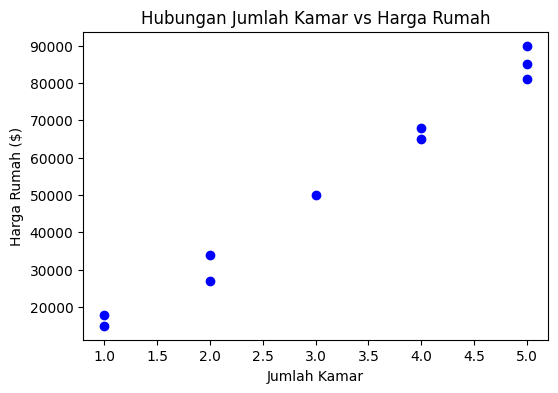

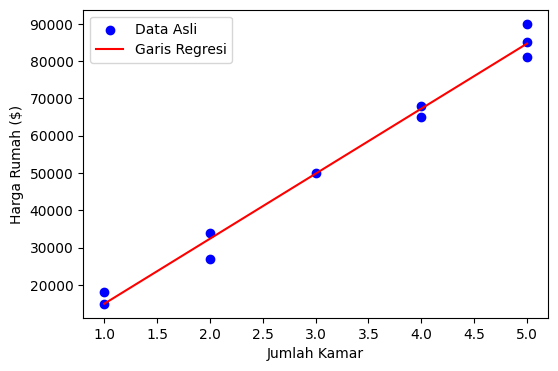

Jumlah kamar: 6 -> Prediksi harga: $102,110.17
Jumlah kamar: 7 -> Prediksi harga: $119,542.37
R^2 Score Model: 0.9878


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

# Data dummy
bedrooms = np.array([1, 1, 2, 2, 3, 4, 4, 5, 5, 5])
house_price = np.array([15000, 18000, 27000, 34000, 50000, 68000, 65000, 81000, 85000, 90000])

# Scatter plot awal
plt.figure(figsize=(6, 4))
plt.scatter(bedrooms, house_price, color='blue', label='Data Asli')
plt.xlabel('Jumlah Kamar')
plt.ylabel('Harga Rumah ($)')
plt.title('Hubungan Jumlah Kamar vs Harga Rumah')
plt.show()

# Training Linear Regression
bedrooms_reshaped = bedrooms.reshape(-1, 1)
linreg = LinearRegression()
linreg.fit(bedrooms_reshaped, house_price)

# Plot Garis Regresi
plt.figure(figsize=(6, 4))
plt.scatter(bedrooms, house_price, color='blue', label='Data Asli')
plt.plot(bedrooms_reshaped, linreg.predict(bedrooms_reshaped), color='red', label='Garis Regresi')
plt.xlabel('Jumlah Kamar')
plt.ylabel('Harga Rumah ($)')
plt.legend()
plt.show()

# Testing Prediksi
X_test = np.array([[6], [7]])
y_pred = linreg.predict(X_test)

for i in range(len(X_test)):
    print(f"Jumlah kamar: {X_test[i][0]} -> Prediksi harga: ${y_pred[i]:,.2f}")

# Evaluasi R^2 Score
r2_score = linreg.score(bedrooms_reshaped, house_price)
print(f"R^2 Score Model: {r2_score:.4f}")

In [3]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression

# Generate Dataset Sintetis Social Network Ads
np.random.seed(42)
n_samples = 400
df = pd.DataFrame({
    'User ID': np.arange(1000, 1000 + n_samples),
    'Gender': np.random.choice(['Male', 'Female'], n_samples),
    'Age': np.random.randint(18, 60, n_samples),
    'EstimatedSalary': np.random.randint(15000, 150000, n_samples),
})
# Target variabel berdasarkan logika sederhana + noise
df['Purchased'] = ((df['Age'] * 0.05 + df['EstimatedSalary'] * 0.00003 + np.random.normal(0, 1, n_samples)) > 3.5).astype(int)

# Preprocessing
data = df.drop(columns=['User ID'])
data = pd.get_dummies(data, columns=['Gender'])

X = data[['Age', 'EstimatedSalary', 'Gender_Female', 'Gender_Male']]
y = data['Purchased']

# Scaling
scaler = StandardScaler()
scaled_X = scaler.fit_transform(X)
scaled_df = pd.DataFrame(scaled_X, columns=X.columns)

# Split & Train
X_train, X_test, y_train, y_test = train_test_split(scaled_df, y, test_size=0.2, random_state=1)
model = LogisticRegression()
model.fit(X_train, y_train)

# Accuracy
acc = model.score(X_test, y_test)
print(f"Akurasi Logistic Regression (Latihan 3): {acc * 100:.2f}%")

Akurasi Logistic Regression (Latihan 3): 86.25%


In [4]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# 1. Generate Dataset Transaksi Konsumen Sintetis
np.random.seed(42)
n = 1000
data_transaksi = pd.DataFrame({
    'Usia': np.random.randint(18, 65, n),
    'Pendapatan_Bulanan': np.random.randint(3000000, 25000000, n),
    'Skor_Kredit': np.random.randint(300, 850, n),
    'Total_Kunjungan_Web': np.random.randint(1, 50, n),
    'Melakukan_Transaksi': np.random.choice([0, 1], size=n, p=[0.6, 0.4])
})

# Split Atribut & Label
X = data_transaksi.drop(columns=['Melakukan_Transaksi'])
y = data_transaksi['Melakukan_Transaksi']

# Scaling Data
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split Train-Test
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

print("==================================================")
print(" 1. BASELINE MODEL EVALUATION")
print("==================================================")

# Baseline Decision Tree
dt_base = DecisionTreeClassifier(random_state=42)
dt_base.fit(X_train, y_train)
y_pred_dt_base = dt_base.predict(X_test)
acc_dt_base = accuracy_score(y_test, y_pred_dt_base)

# Baseline Logistic Regression
lr_base = LogisticRegression(random_state=42)
lr_base.fit(X_train, y_train)
y_pred_lr_base = lr_base.predict(X_test)
acc_lr_base = accuracy_score(y_test, y_pred_lr_base)

print(f"Akurasi Baseline Decision Tree    : {acc_dt_base * 100:.2f}%")
print(f"Akurasi Baseline Logistic Regress : {acc_lr_base * 100:.2f}%")

print("\n==================================================")
print(" 2. HYPERPARAMETER TUNING (GRIDSEARCHCV)")
print("==================================================")

# Tuning Decision Tree
param_grid_dt = {
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 5, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid_dt, cv=5, scoring='accuracy')
grid_dt.fit(X_train, y_train)

best_dt = grid_dt.best_estimator_
acc_dt_tuned = accuracy_score(y_test, best_dt.predict(X_test))

# Tuning Logistic Regression
param_grid_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'penalty': ['l2']
}
grid_lr = GridSearchCV(LogisticRegression(random_state=42), param_grid_lr, cv=5, scoring='accuracy')
grid_lr.fit(X_train, y_train)

best_lr = grid_lr.best_estimator_
acc_lr_tuned = accuracy_score(y_test, best_lr.predict(X_test))

print(f"Best Params DT : {grid_dt.best_params_}")
print(f"Akurasi Tuned Decision Tree    : {acc_dt_tuned * 100:.2f}%")
print(f"\nBest Params LR : {grid_lr.best_params_}")
print(f"Akurasi Tuned Logistic Regress : {acc_lr_tuned * 100:.2f}%")

print("\n==================================================")
print(" 3. PERBANDINGAN HASIL & ANALISIS")
print("==================================================")
if acc_dt_tuned > acc_lr_tuned:
    print("Algoritma terbaik: Decision Tree")
elif acc_lr_tuned > acc_dt_tuned:
    print("Algoritma terbaik: Logistic Regression")
else:
    print("Kedua algoritma menghasilkan akurasi yang sama.")

 1. BASELINE MODEL EVALUATION
Akurasi Baseline Decision Tree    : 53.50%
Akurasi Baseline Logistic Regress : 56.00%

 2. HYPERPARAMETER TUNING (GRIDSEARCHCV)
Best Params DT : {'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 10}
Akurasi Tuned Decision Tree    : 50.50%

Best Params LR : {'C': 0.01, 'penalty': 'l2', 'solver': 'liblinear'}
Akurasi Tuned Logistic Regress : 56.00%

 3. PERBANDINGAN HASIL & ANALISIS
Algoritma terbaik: Logistic Regression


--- Hasil Evaluasi Regresi Linear Gaji ---
Persamaan Garis : Gaji = 3,116,922.38 + (1,480,232.22 * MasaKerja)
Mean Squared Error (MSE): 509,401,736,291.48
R-squared (R2) Score    : 0.9637


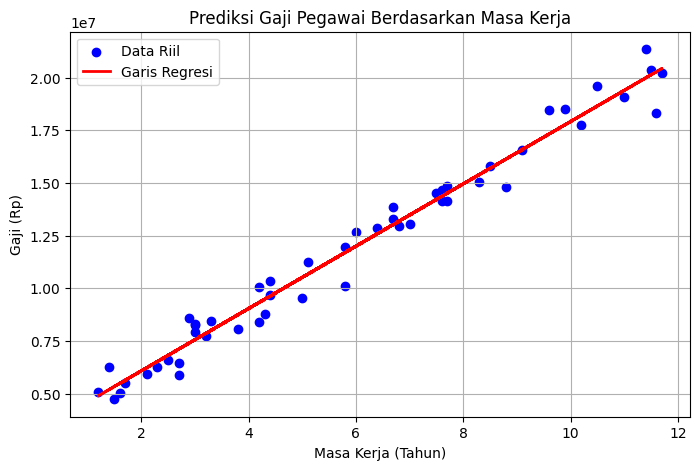

Masa Kerja: 3.5 tahun -> Estimasi Gaji: Rp 8,297,735.14
Masa Kerja: 8.0 tahun -> Estimasi Gaji: Rp 14,958,780.11


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# 1. Generate Dataset Masa Kerja vs Gaji Sintetis
np.random.seed(42)
years_experience = np.random.uniform(1, 12, 50).round(1)
salary = (3000000 + years_experience * 1500000 + np.random.normal(0, 800000, 50)).round(-3)

df_gaji = pd.DataFrame({
    'MasaKerja_Tahun': years_experience,
    'Gaji_IDR': salary
})

X_gaji = df_gaji[['MasaKerja_Tahun']]
y_gaji = df_gaji['Gaji_IDR']

# Split Data
X_tr, X_ts, y_tr, y_ts = train_test_split(X_gaji, y_gaji, test_size=0.2, random_state=42)

# Training Model
reg_gaji = LinearRegression()
reg_gaji.fit(X_tr, y_tr)

# Prediksi
y_pred_gaji = reg_gaji.predict(X_ts)

# Evaluasi Performance
mse = mean_squared_error(y_ts, y_pred_gaji)
r2 = r2_score(y_ts, y_pred_gaji)

print("--- Hasil Evaluasi Regresi Linear Gaji ---")
print(f"Persamaan Garis : Gaji = {reg_gaji.intercept_:,.2f} + ({reg_gaji.coef_[0]:,.2f} * MasaKerja)")
print(f"Mean Squared Error (MSE): {mse:,.2f}")
print(f"R-squared (R2) Score    : {r2:.4f}")

# Plot Visualisasi
plt.figure(figsize=(8, 5))
plt.scatter(X_gaji, y_gaji, color='blue', label='Data Riil')
plt.plot(X_gaji, reg_gaji.predict(X_gaji), color='red', linewidth=2, label='Garis Regresi')
plt.xlabel('Masa Kerja (Tahun)')
plt.ylabel('Gaji (Rp)')
plt.title('Prediksi Gaji Pegawai Berdasarkan Masa Kerja')
plt.legend()
plt.grid(True)
plt.show()

# Contoh Prediksi untuk Masa Kerja Baru
sample_exp = [[3.5], [8.0]]
sample_pred = reg_gaji.predict(sample_exp)
for exp, pred in zip(sample_exp, sample_pred):
    print(f"Masa Kerja: {exp[0]} tahun -> Estimasi Gaji: Rp {pred:,.2f}")